In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_pickle('data/04_famafrench_stocksWithBetas.pkl')

Now at this moment we are ready to apply ML models on the data now as we are ready with the data 

## 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

### K-Means Clustering
* You may want to initialize predefined centroids for each cluster based on your research.

* For visualization purpose of this tutorial we will initially rely on the ‘k-means++’ initialization.

* Then we will pre-define our centroids for each cluster.

In [3]:
data

high  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2020-08-31 AAPL    126.957042          0.000707  76.744809  4.634849   
           ABBV     76.142956          0.000105  52.776389  4.304350   
           ABT      99.894561          0.000204  67.784280  4.460974   
           ACN     221.241397          0.000094  67.876178  5.324580   
           ADBE    516.729980          0.000153  66.121887  6.036542   
...                       ...               ...        ...       ...   
2026-08-31 WDAY    178.529999          0.000461  62.482008  4.846323   
           WFC      89.220001          0.000170  59.174628  4.444806   
           WMT     116.050003          0.000153  54.108979  4.693527   
           XOM     159.199152          0.000119  62.142821  4.988154   
           XYZ      79.199997          0.000312  49.935831  4.342263   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2020-08-31 AAPL    4.743995  4.853141 -0.215957  1.968695   0.204976   
           ABBV    4.329241  4.354133 -1.060942 -0.352670   0.009061   
           ABT     4.528430  4.595886  0.635079  1.529678   0.087738   
           ACN     5.364798  5.405016 -1.217038  0.870915   0.067399   
           ADBE    6.152162  6.267782  0.679071  1.881340   0.155451   
...                     ...       ...       ...       ...        ...   
2026-08-31 WDAY    5.065030  5.283738  1.565843  2.206199   0.093239   
           WFC     4.474222  4.503639  1.216887  0.744505   0.034593   
           WMT     4.727599  4.761672  2.212910 -0.599633   0.043255   
           XOM     5.038804  5.089454  2.227161  1.943697   0.027728   
           XYZ     4.398908  4.455553 -0.668036  0.144249  -0.036435   

                   return_2m  return_3m  return_6m  return_9m  return_12m  \
date       ticker                                                           
2020-08-31 AAPL     0.176611   0.158586   0.110026   0.076700    0.073806   
           ABBV    -0.006341   0.015125   0.023252   0.014328    0.036576   
           ABT      0.096338   0.050042   0.059706   0.029314    0.022377   
           ACN      0.059010   0.060994   0.049919   0.021139    0.017444   
           ADBE     0.085986   0.099162   0.068430   0.057830    0.050419   
...                      ...        ...        ...        ...         ...   
2026-08-31 WDAY     0.192618   0.062380   0.046097  -0.022746   -0.022672   
           WFC      0.040332   0.048744   0.016685   0.005747    0.008411   
           WMT      0.012067   0.000748  -0.015546   0.006081    0.015550   
           XOM      0.080947   0.032203   0.008908   0.037822    0.030196   
           XYZ      0.014889   0.011145   0.034948   0.017777   -0.001434   

                     Mkt-RF       SMB       HML       RMW       CMA  
date       ticker                                                    
2020-08-31 AAPL    1.018473  0.091631 -0.410227  0.442392 -0.082594  
           ABBV    0.488717 -0.315094  0.399168  0.138334  0.707258  
           ABT     0.797525 -0.230780  0.080680 -0.126645  0.747452  
           ACN     1.055670 -0.080026 -0.175076 -0.012285 -0.253985  
           ADBE    1.594977 -0.804373  0.044982  0.310262 -0.269681  
...                     ...       ...       ...       ...       ...  
2026-08-31 WDAY    1.041123 -0.833658 -0.200310 -1.315976 -0.196809  
           WFC     1.025111 -0.081648  1.304222 -0.959372 -0.829003  
           WMT     0.712885 -0.102831 -0.285567  0.416614  0.104237  
           XOM     0.677901 -0.234842  0.975004  0.033052  0.335005  
           XYZ     2.245977  0.630212 -0.304450 -2.658683  0.312698  

[10135 rows x 19 columns]

In [4]:
data = data.drop(['high'], axis=1)
data = data.dropna()
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-08-31 AAPL            0.000707  76.744809  4.634849  4.743995  4.853141   
           ABBV            0.000105  52.776389  4.304350  4.329241  4.354133   
           ABT             0.000204  67.784280  4.460974  4.528430  4.595886   
           ACN             0.000094  67.876178  5.324580  5.364798  5.405016   
           ADBE            0.000153  66.121887  6.036542  6.152162  6.267782   
...                             ...        ...       ...       ...       ...   
2026-08-31 WDAY            0.000461  62.482008  4.846323  5.065030  5.283738   
           WFC             0.000170  59.174628  4.444806  4.474222  4.503639   
           WMT             0.000153  54.108979  4.693527  4.727599  4.761672   
           XOM             0.000119  62.142821  4.988154  5.038804  5.089454   
           XYZ             0.000312  49.935831  4.342263  4.398908  4.455553   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-08-31 AAPL   -0.215957  1.968695   0.204976   0.176611   0.158586   
           ABBV   -1.060942 -0.352670   0.009061  -0.006341   0.015125   
           ABT     0.635079  1.529678   0.087738   0.096338   0.050042   
           ACN    -1.217038  0.870915   0.067399   0.059010   0.060994   
           ADBE    0.679071  1.881340   0.155451   0.085986   0.099162   
...                     ...       ...        ...        ...        ...   
2026-08-31 WDAY    1.565843  2.206199   0.093239   0.192618   0.062380   
           WFC     1.216887  0.744505   0.034593   0.040332   0.048744   
           WMT     2.212910 -0.599633   0.043255   0.012067   0.000748   
           XOM     2.227161  1.943697   0.027728   0.080947   0.032203   
           XYZ    -0.668036  0.144249  -0.036435   0.014889   0.011145   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-08-31 AAPL     0.110026   0.076700    0.073806  1.018473  0.091631   
           ABBV     0.023252   0.014328    0.036576  0.488717 -0.315094   
           ABT      0.059706   0.029314    0.022377  0.797525 -0.230780   
           ACN      0.049919   0.021139    0.017444  1.055670 -0.080026   
           ADBE     0.068430   0.057830    0.050419  1.594977 -0.804373   
...                      ...        ...         ...       ...       ...   
2026-08-31 WDAY     0.046097  -0.022746   -0.022672  1.041123 -0.833658   
           WFC      0.016685   0.005747    0.008411  1.025111 -0.081648   
           WMT     -0.015546   0.006081    0.015550  0.712885 -0.102831   
           XOM      0.008908   0.037822    0.030196  0.677901 -0.234842   
           XYZ      0.034948   0.017777   -0.001434  2.245977  0.630212   

                        HML       RMW       CMA  
date       ticker                                
2020-08-31 AAPL   -0.410227  0.442392 -0.082594  
           ABBV    0.399168  0.138334  0.707258  
           ABT     0.080680 -0.126645  0.747452  
           ACN    -0.175076 -0.012285 -0.253985  
           ADBE    0.044982  0.310262 -0.269681  
...                     ...       ...       ...  
2026-08-31 WDAY   -0.200310 -1.315976 -0.196809  
           WFC     1.304222 -0.959372 -0.829003  
           WMT    -0.285567  0.416614  0.104237  
           XOM     0.975004  0.033052  0.335005  
           XYZ    -0.304450 -2.658683  0.312698  

[10135 rows x 18 columns]

In [5]:
target_rsi_values = [30,45,55,70]

initial_centroids = np.zeros((len(target_rsi_values),18))

initial_centroids

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [6]:
initial_centroids[:,1] = target_rsi_values
initial_centroids

array([[ 0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [7]:
from sklearn.cluster import KMeans
data = data.drop(columns=['cluster'],errors='ignore')
def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,random_state=0,init=initial_centroids).fit(df).labels_

    return df

In [8]:
data = data.groupby('date',group_keys=False).apply(get_clusters)

In [9]:
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-08-31 AAPL            0.000707  76.744809  4.634849  4.743995  4.853141   
           ABBV            0.000105  52.776389  4.304350  4.329241  4.354133   
           ABT             0.000204  67.784280  4.460974  4.528430  4.595886   
           ACN             0.000094  67.876178  5.324580  5.364798  5.405016   
           ADBE            0.000153  66.121887  6.036542  6.152162  6.267782   
...                             ...        ...       ...       ...       ...   
2026-08-31 WDAY            0.000461  62.482008  4.846323  5.065030  5.283738   
           WFC             0.000170  59.174628  4.444806  4.474222  4.503639   
           WMT             0.000153  54.108979  4.693527  4.727599  4.761672   
           XOM             0.000119  62.142821  4.988154  5.038804  5.089454   
           XYZ             0.000312  49.935831  4.342263  4.398908  4.455553   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-08-31 AAPL   -0.215957  1.968695   0.204976   0.176611   0.158586   
           ABBV   -1.060942 -0.352670   0.009061  -0.006341   0.015125   
           ABT     0.635079  1.529678   0.087738   0.096338   0.050042   
           ACN    -1.217038  0.870915   0.067399   0.059010   0.060994   
           ADBE    0.679071  1.881340   0.155451   0.085986   0.099162   
...                     ...       ...        ...        ...        ...   
2026-08-31 WDAY    1.565843  2.206199   0.093239   0.192618   0.062380   
           WFC     1.216887  0.744505   0.034593   0.040332   0.048744   
           WMT     2.212910 -0.599633   0.043255   0.012067   0.000748   
           XOM     2.227161  1.943697   0.027728   0.080947   0.032203   
           XYZ    -0.668036  0.144249  -0.036435   0.014889   0.011145   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-08-31 AAPL     0.110026   0.076700    0.073806  1.018473  0.091631   
           ABBV     0.023252   0.014328    0.036576  0.488717 -0.315094   
           ABT      0.059706   0.029314    0.022377  0.797525 -0.230780   
           ACN      0.049919   0.021139    0.017444  1.055670 -0.080026   
           ADBE     0.068430   0.057830    0.050419  1.594977 -0.804373   
...                      ...        ...         ...       ...       ...   
2026-08-31 WDAY     0.046097  -0.022746   -0.022672  1.041123 -0.833658   
           WFC      0.016685   0.005747    0.008411  1.025111 -0.081648   
           WMT     -0.015546   0.006081    0.015550  0.712885 -0.102831   
           XOM      0.008908   0.037822    0.030196  0.677901 -0.234842   
           XYZ      0.034948   0.017777   -0.001434  2.245977  0.630212   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-08-31 AAPL   -0.410227  0.442392 -0.082594        3  
           ABBV    0.399168  0.138334  0.707258        1  
           ABT     0.080680 -0.126645  0.747452        3  
           ACN    -0.175076 -0.012285 -0.253985        3  
           ADBE    0.044982  0.310262 -0.269681        2  
...                     ...       ...       ...      ...  
2026-08-31 WDAY   -0.200310 -1.315976 -0.196809        3  
           WFC     1.304222 -0.959372 -0.829003        2  
           WMT    -0.285567  0.416614  0.104237        2  
           XOM     0.975004  0.033052  0.335005        2  
           XYZ    -0.304450 -2.658683  0.312698        0  

[10135 rows x 19 columns]

In [10]:
data.columns.tolist()

['garman_klass_vol',
 'rsi',
 'bb_low',
 'bb_mid',
 'bb_high',
 'atr',
 'macd',
 'return_1m',
 'return_2m',
 'return_3m',
 'return_6m',
 'return_9m',
 'return_12m',
 'Mkt-RF',
 'SMB',
 'HML',
 'RMW',
 'CMA',
 'cluster']

In [11]:
len(data.columns.tolist())

19

In [12]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,6] , cluster_0.iloc[:,1] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,6] , cluster_1.iloc[:,1] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,6] , cluster_2.iloc[:,1] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,6] , cluster_3.iloc[:,1] , color = 'black', label='cluster 3')
    
    plt.legend()
    plt.show()
    return


In [13]:
import matplotlib.pyplot as plt

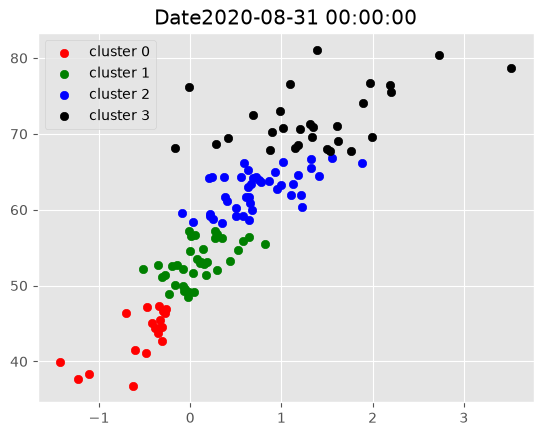

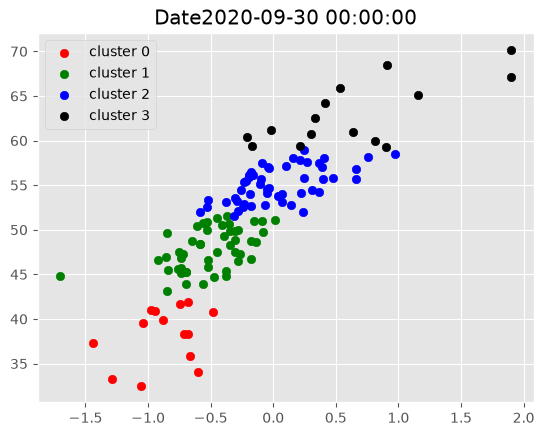

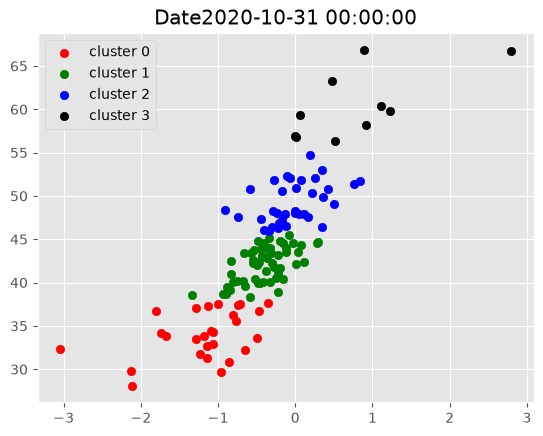

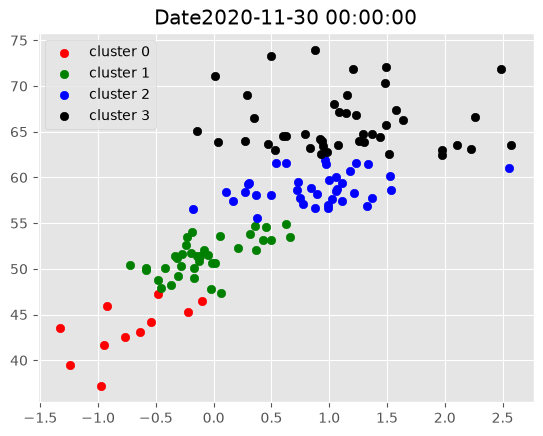

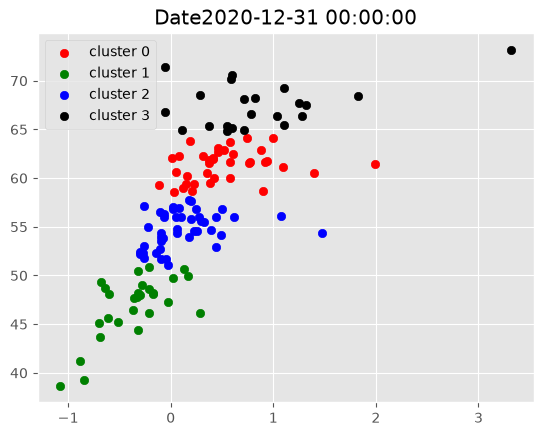

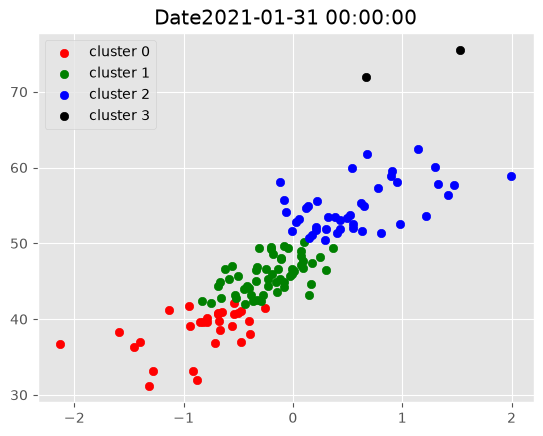

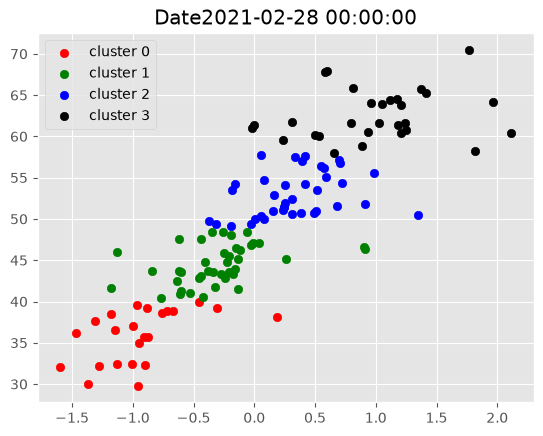

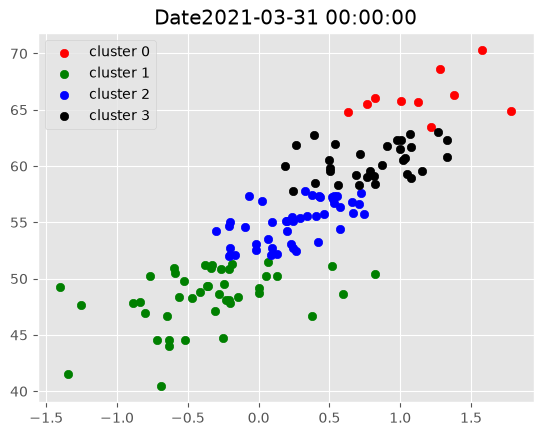

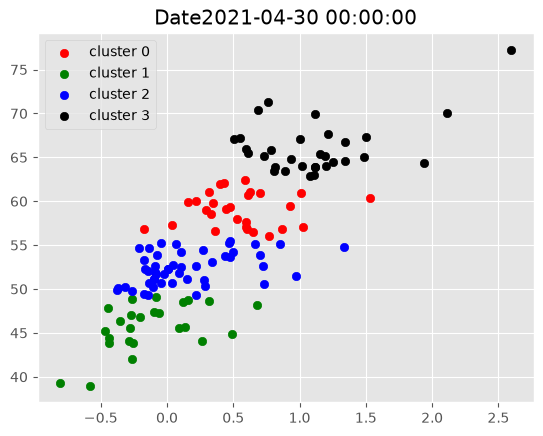

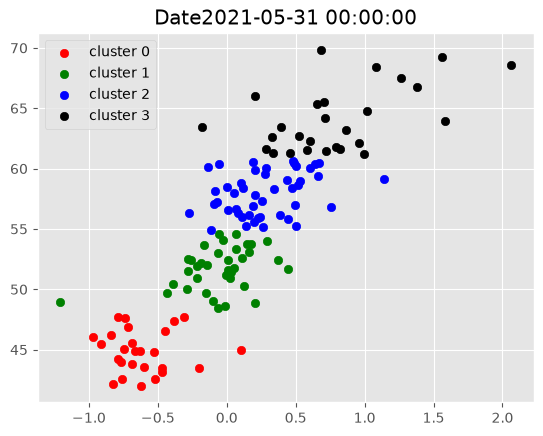

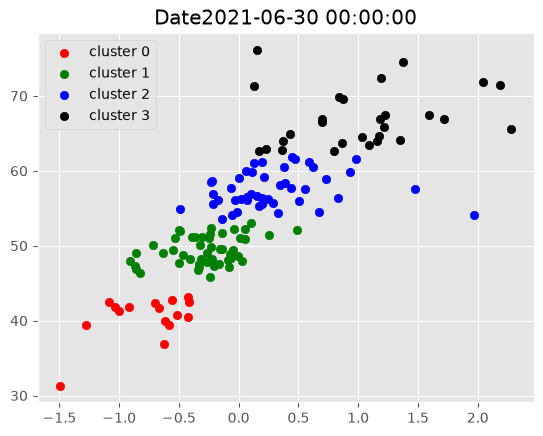

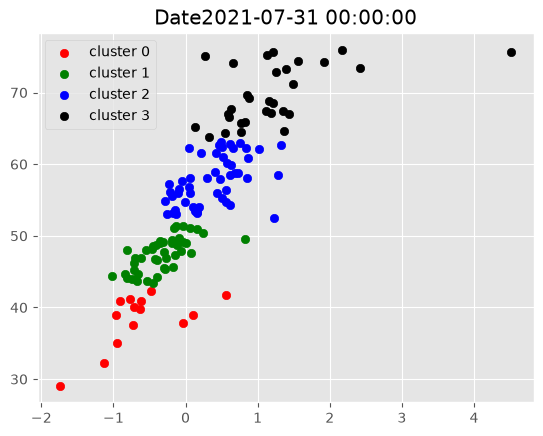

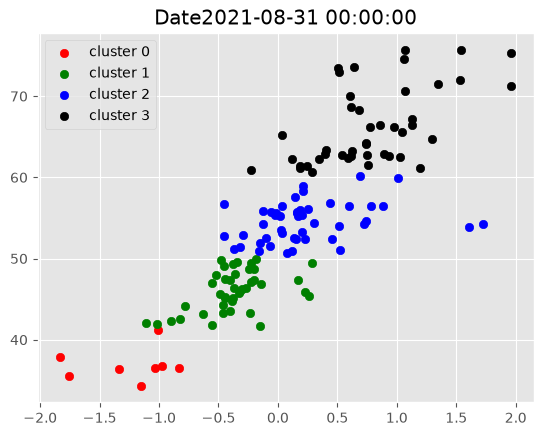

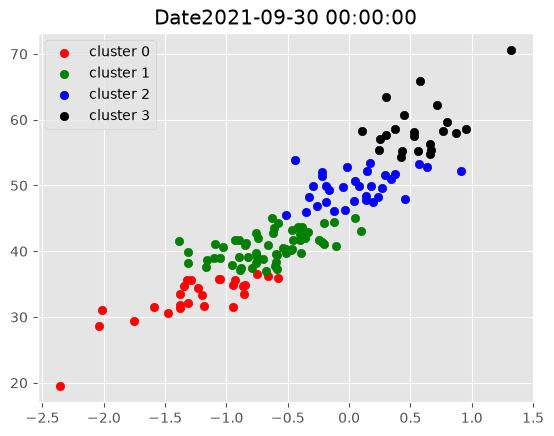

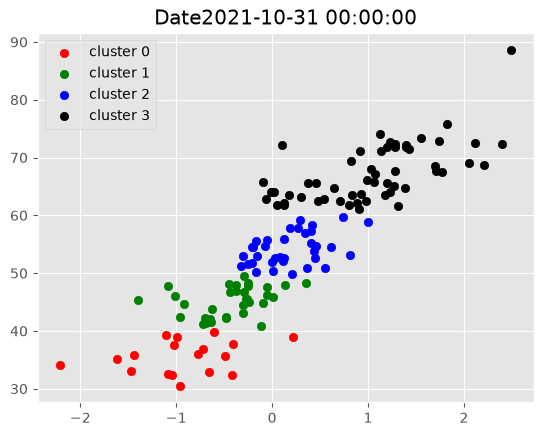

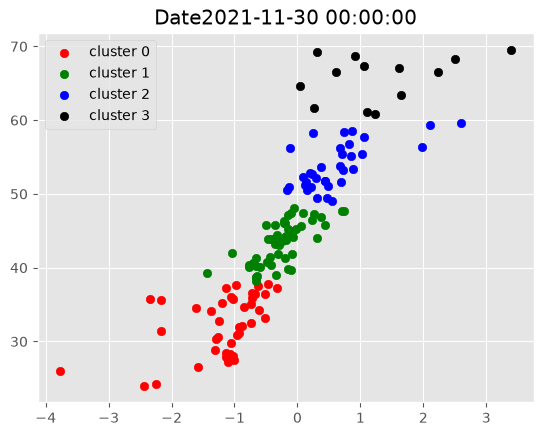

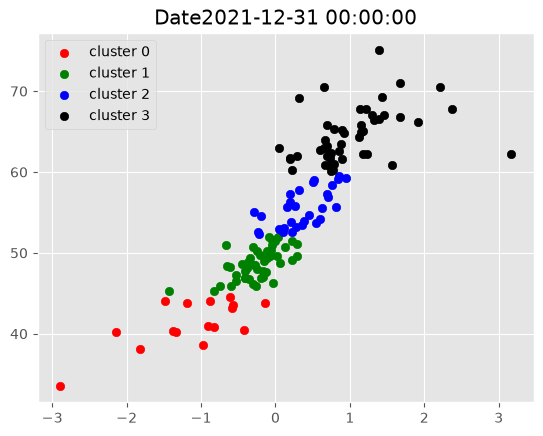

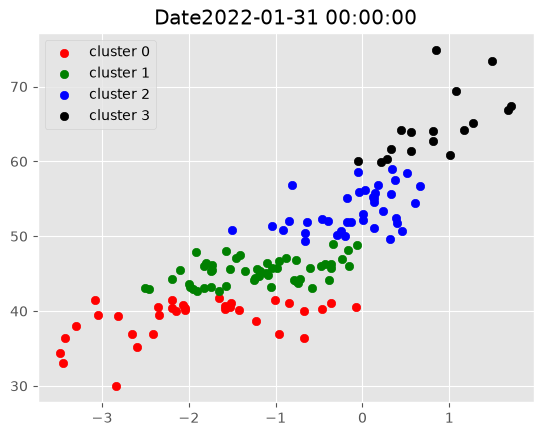

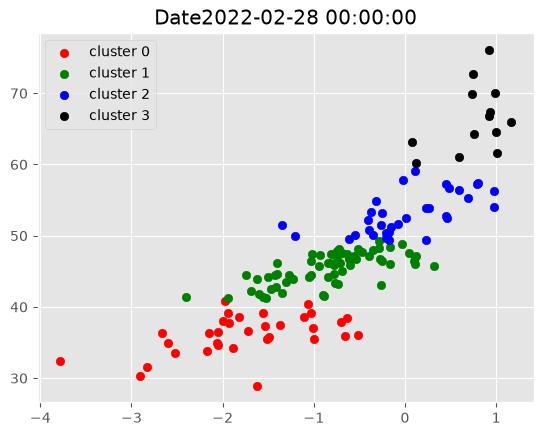

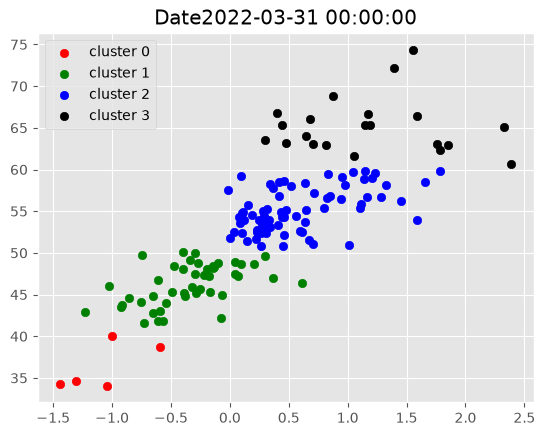

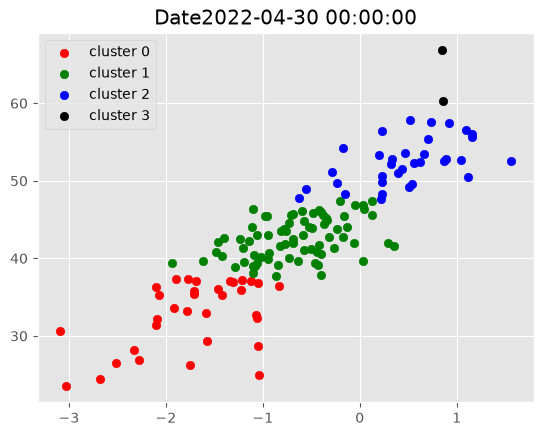

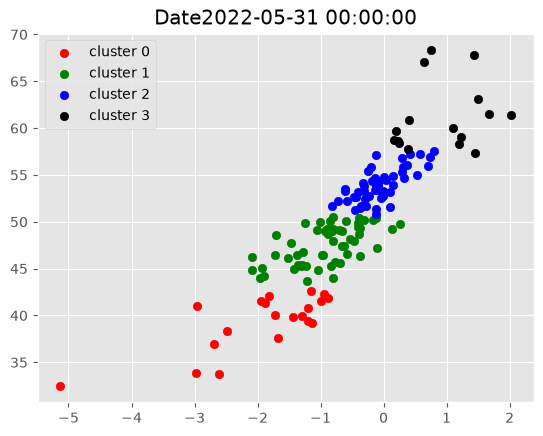

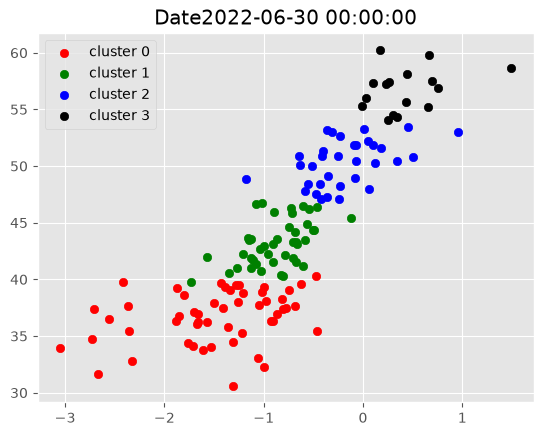

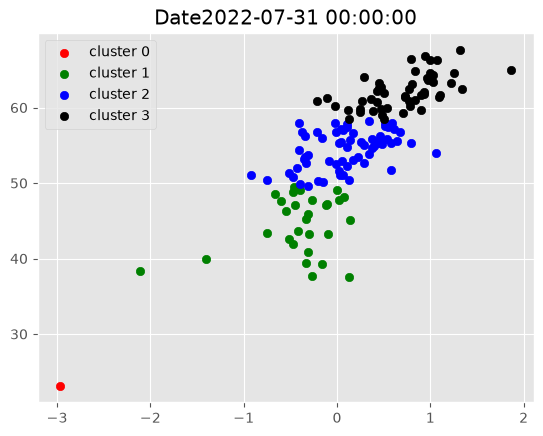

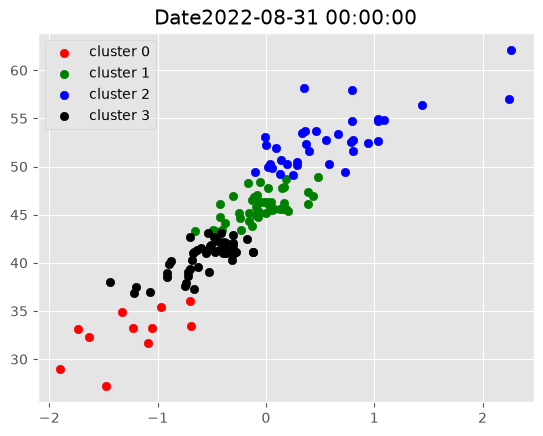

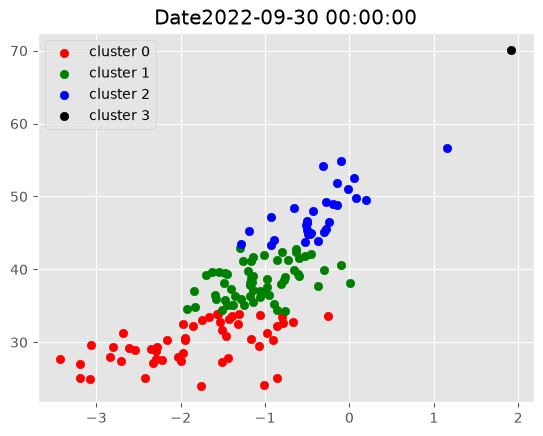

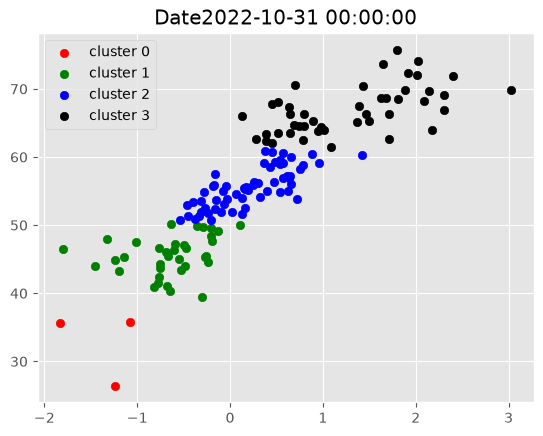

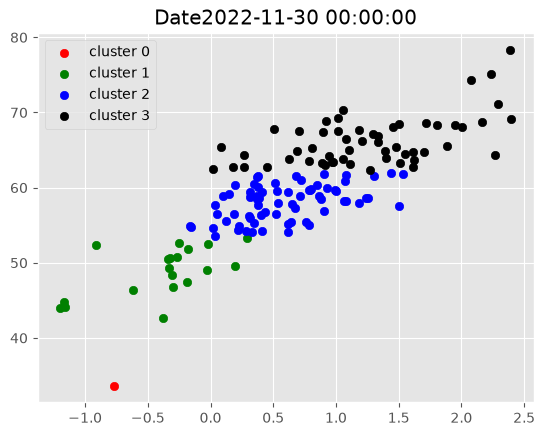

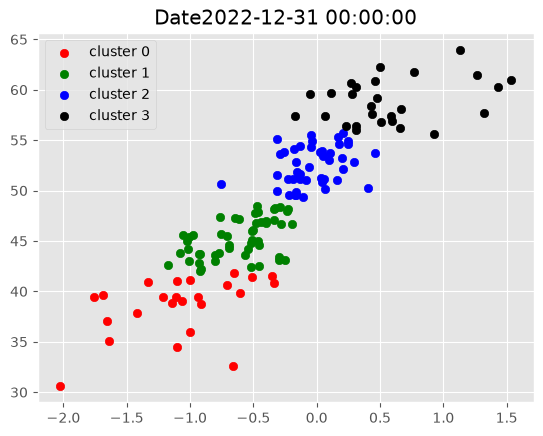

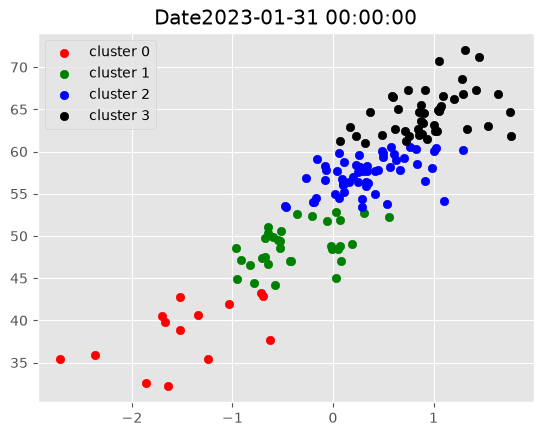

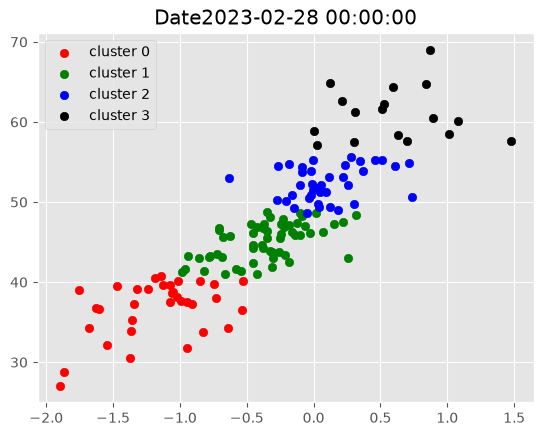

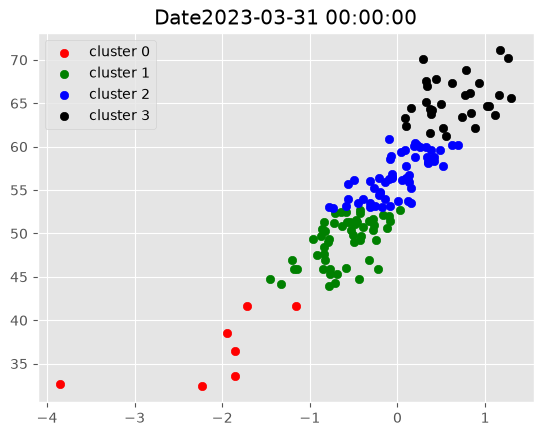

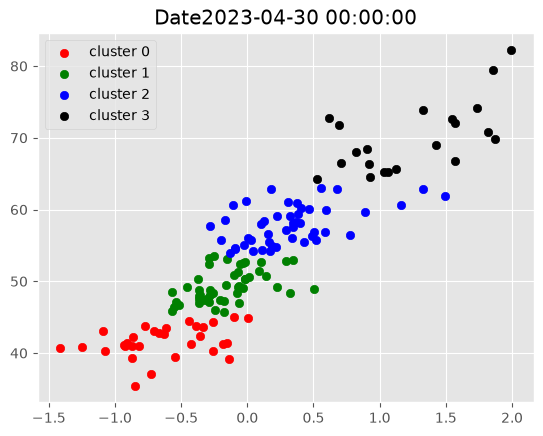

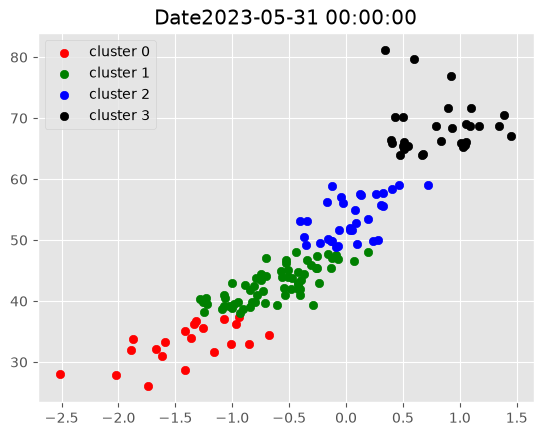

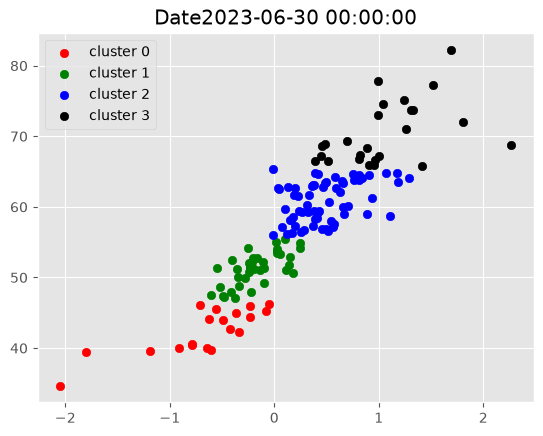

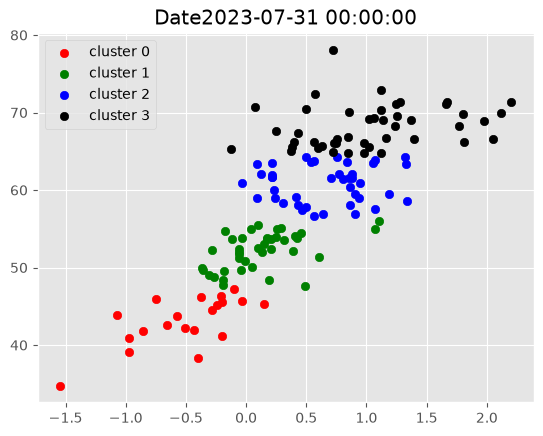

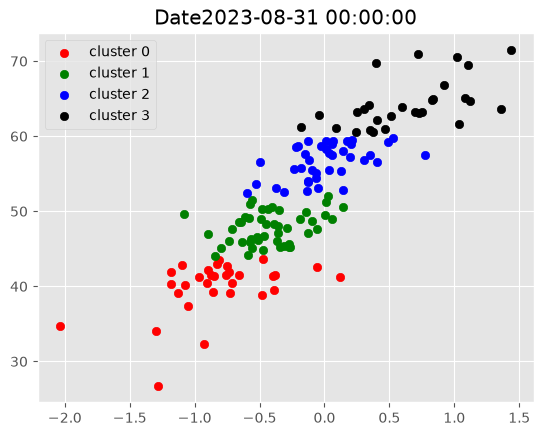

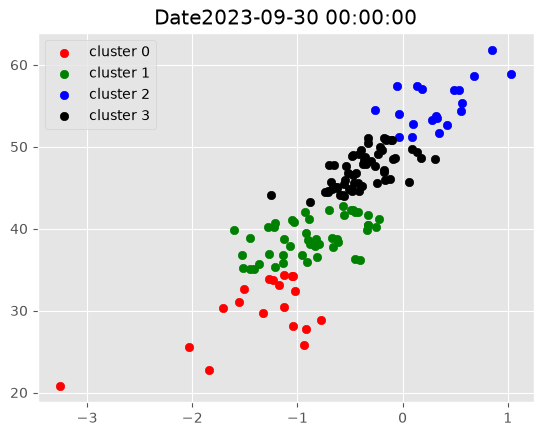

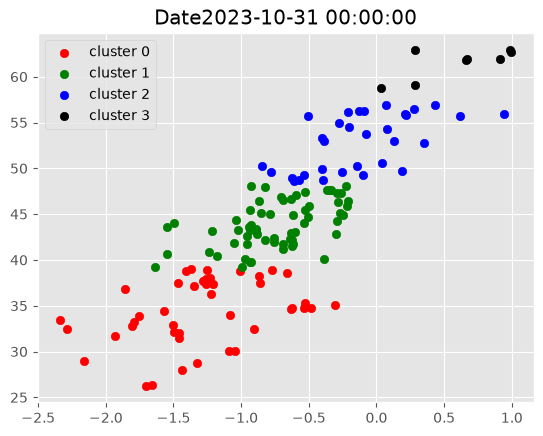

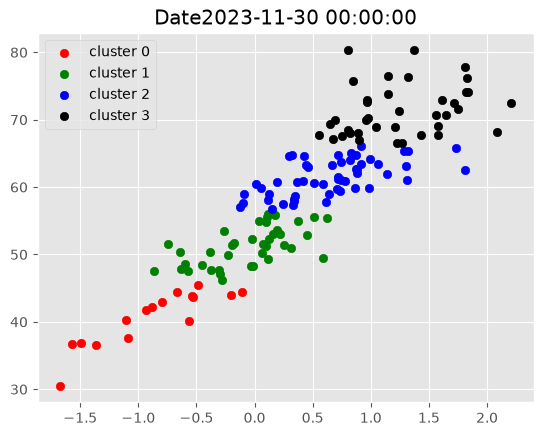

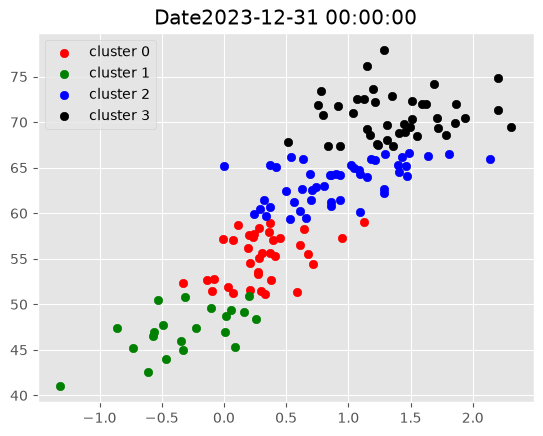

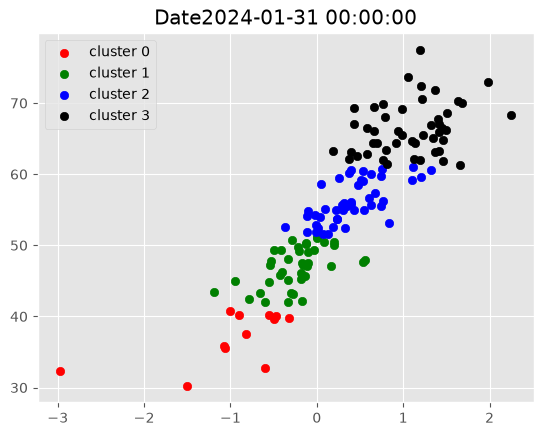

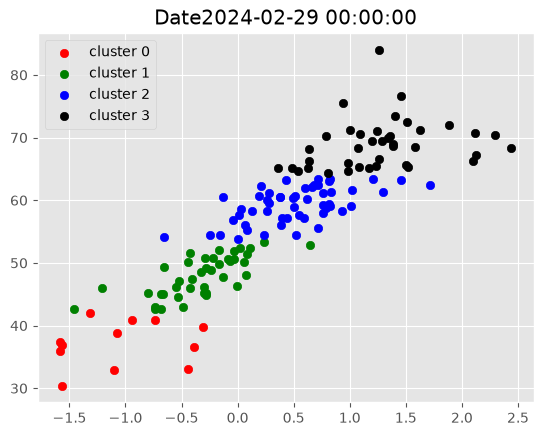

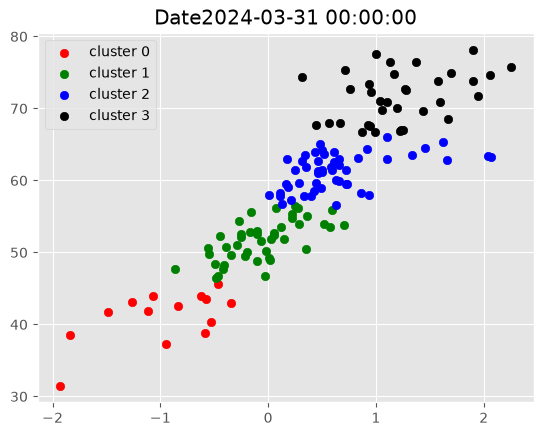

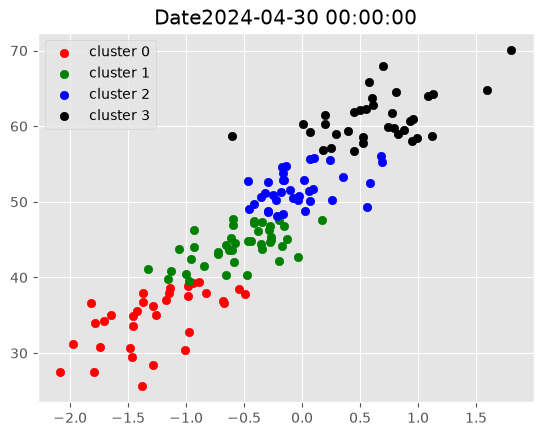

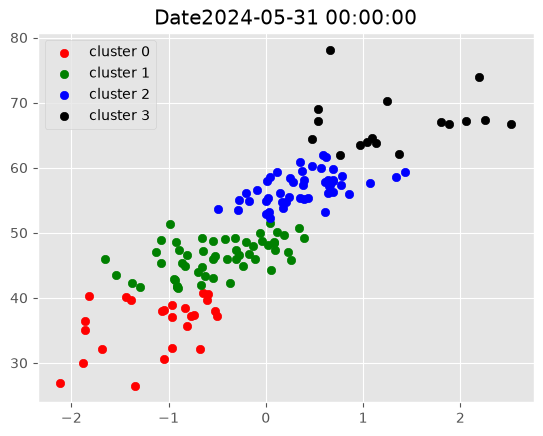

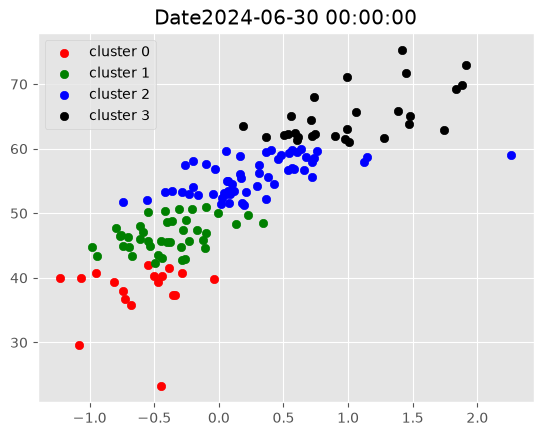

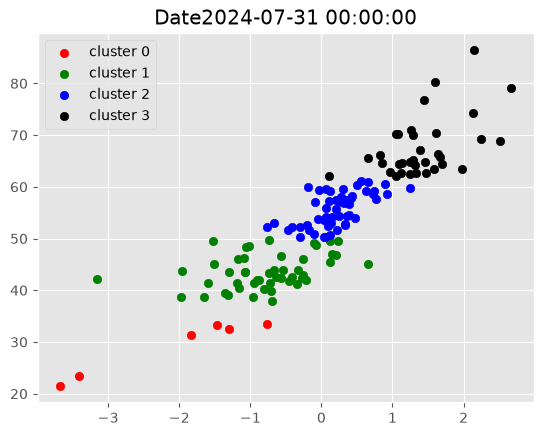

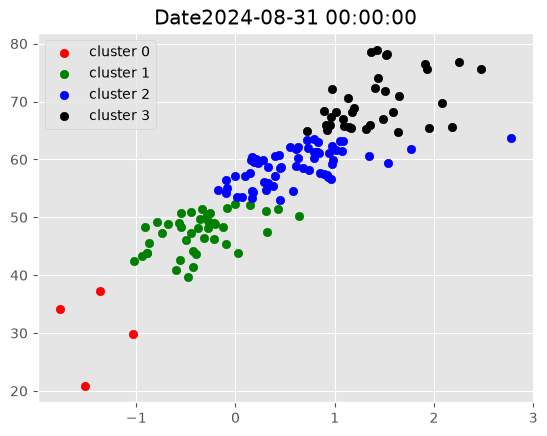

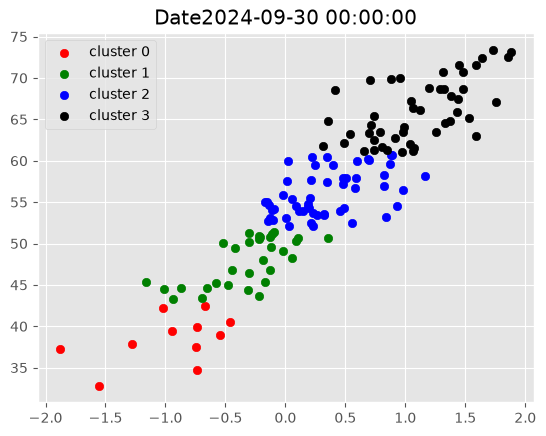

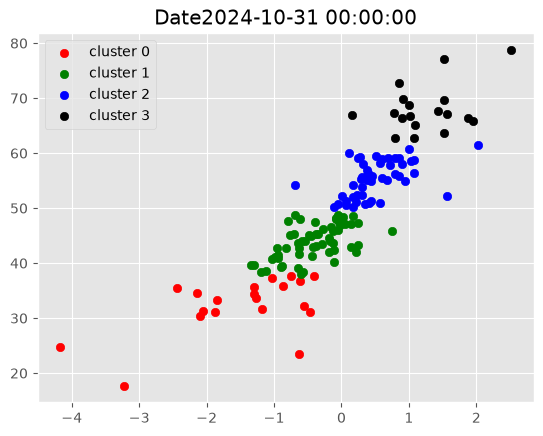

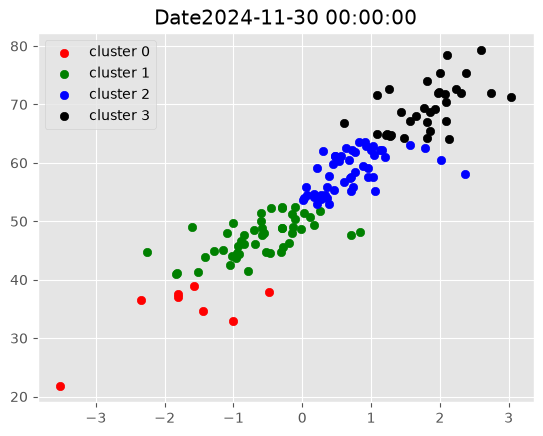

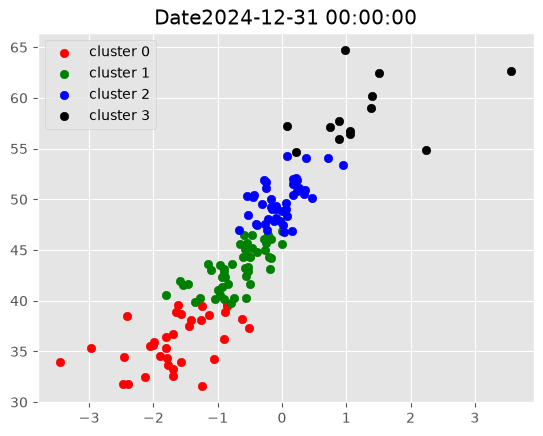

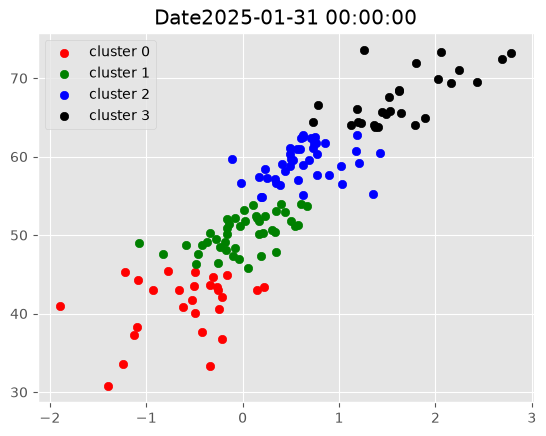

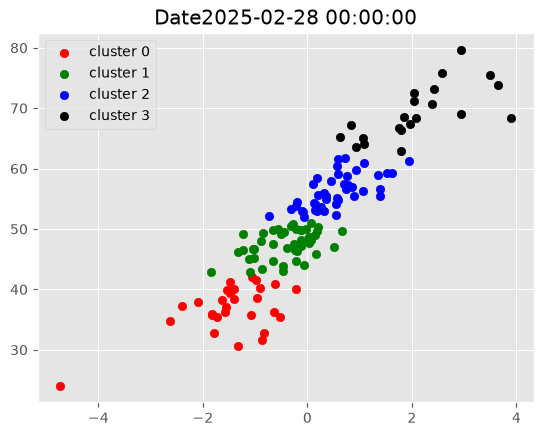

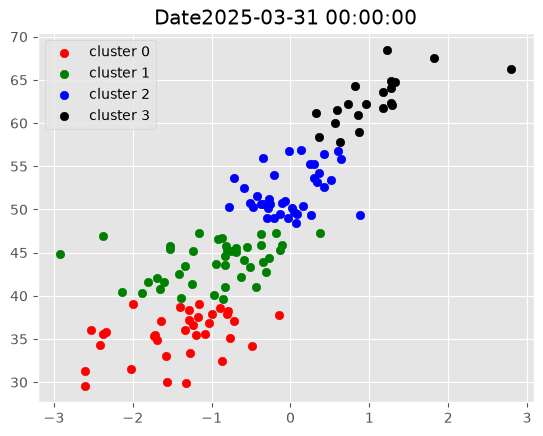

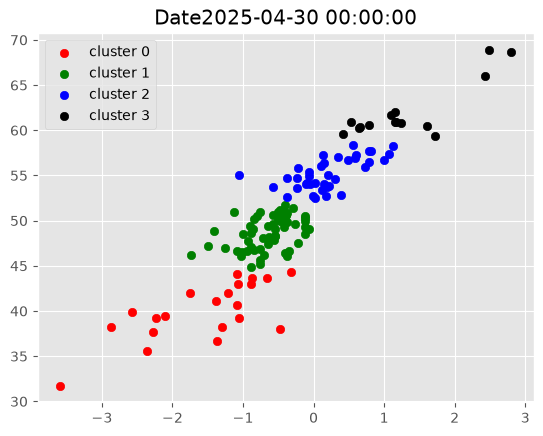

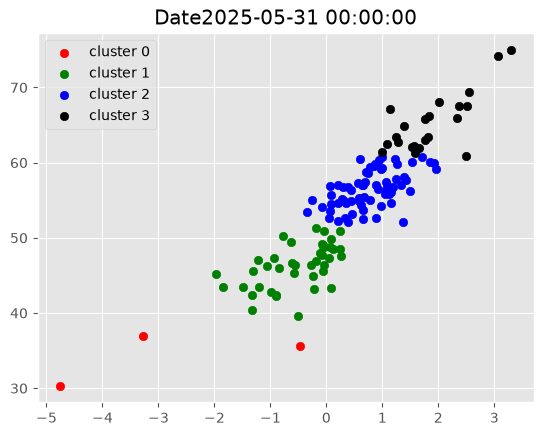

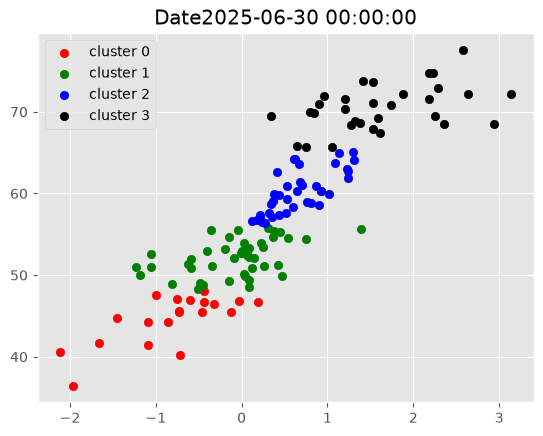

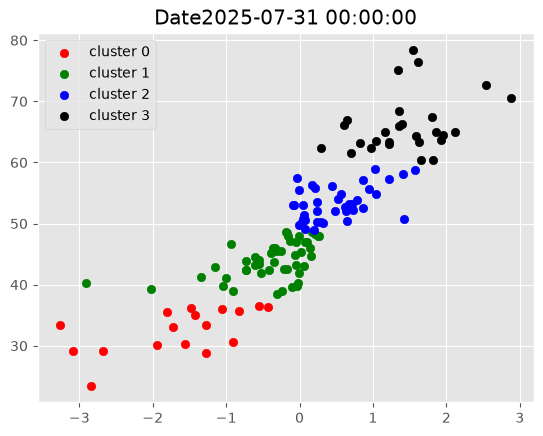

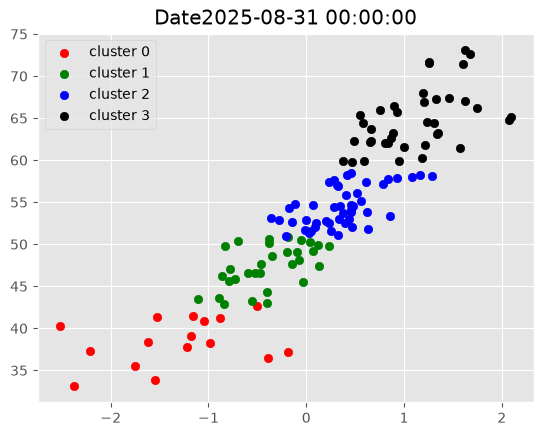

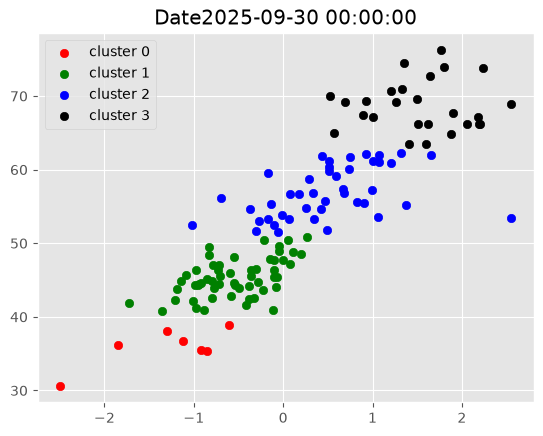

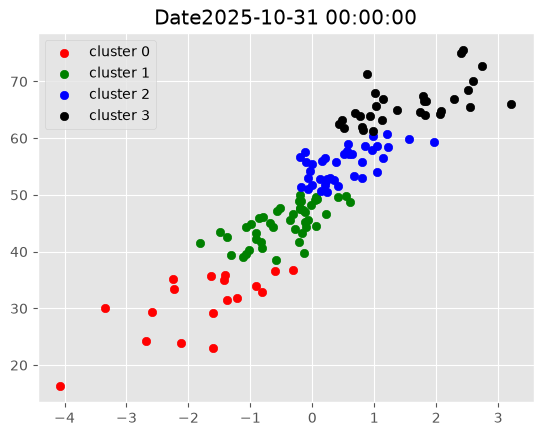

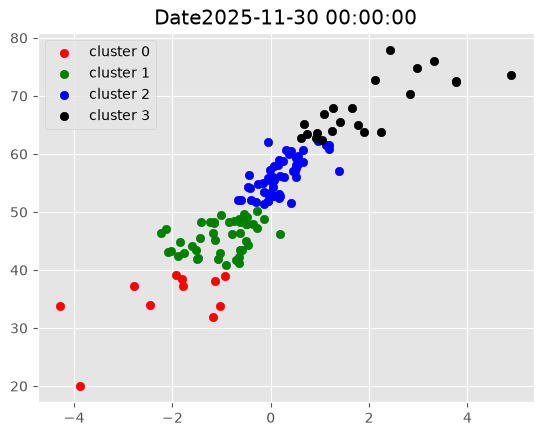

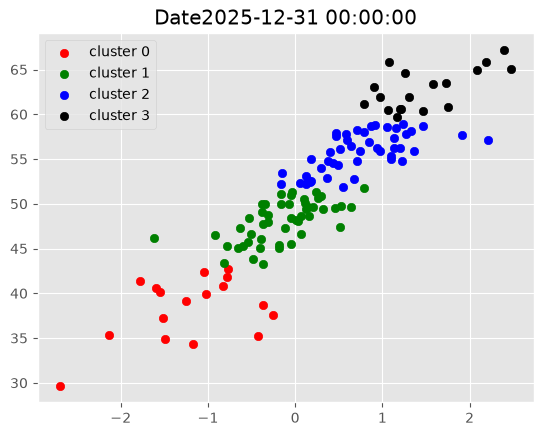

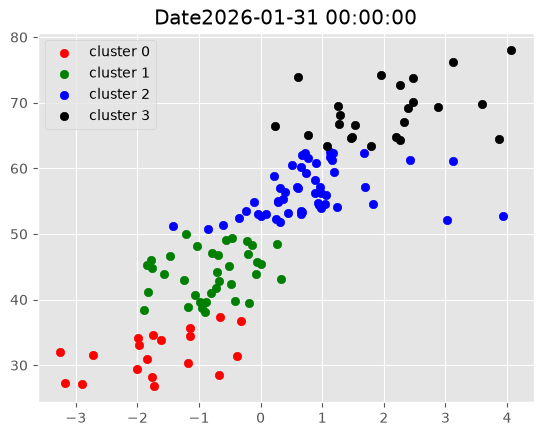

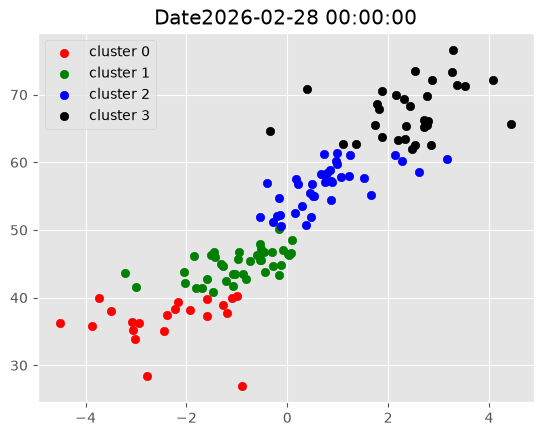

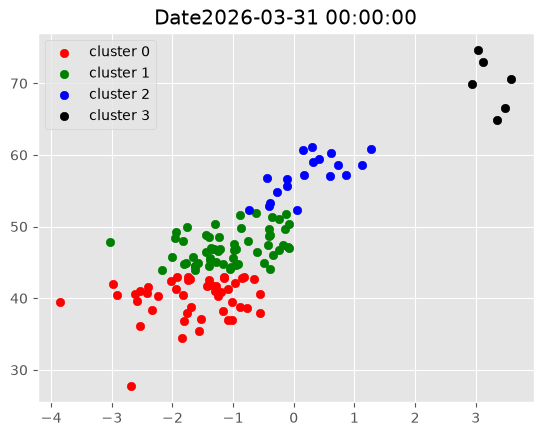

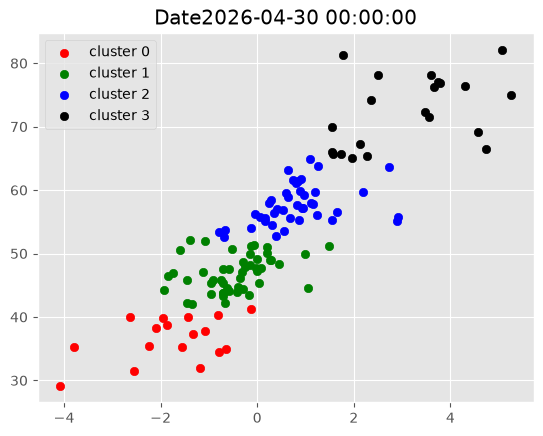

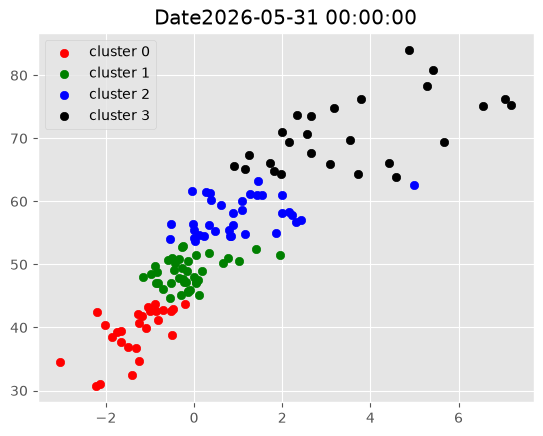

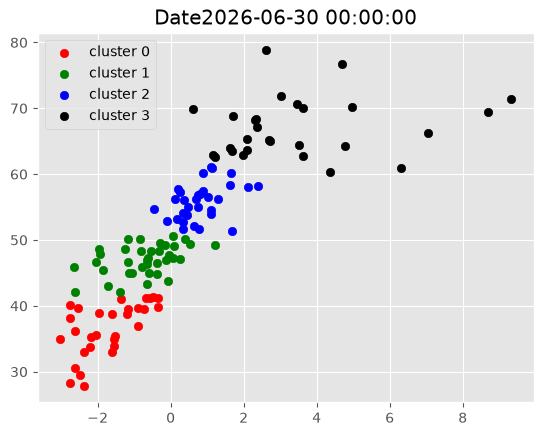

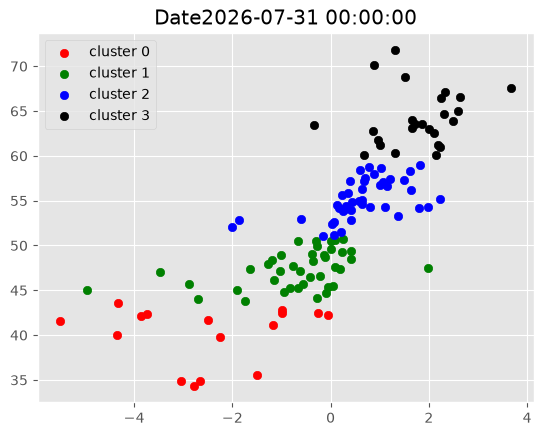

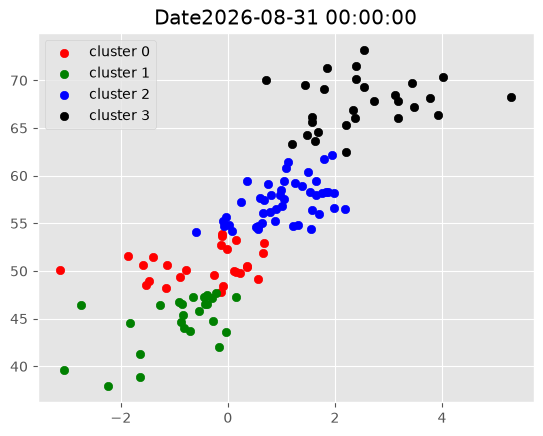

In [14]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():

    g = data.xs(i, level=0)

    plt.title(f'Date{i}')

    plot_clusters(g)

Our strategy is to invest on stocks which have a rsi of greater than 70 than greater than 50 than 45 than 30 , so different clusters

##Apply Pre Defined Coordinates

In [15]:
import numpy as np

In [16]:
target_rsi_values = [30,45,55,70]

initial_centroids = np.zeros((len(target_rsi_values),18))

initial_centroids

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [17]:
data.columns.get_loc('rsi')

1

## 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.

According to lectures

In [18]:
#select those stocks which have higher rsi which are corresponfing to cluster 3
filtered_df = data[data['cluster']==3]
filtered_df

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-08-31 AAPL            0.000707  76.744809  4.634849  4.743995  4.853141   
           ABT             0.000204  67.784280  4.460974  4.528430  4.595886   
           ACN             0.000094  67.876178  5.324580  5.364798  5.405016   
           AMD             0.001989  69.464550  4.371420  4.438667  4.505915   
           AVGO            0.000164  68.197532  3.373570  3.409461  3.445352   
...                             ...        ...       ...       ...       ...   
2026-08-31 TGT             0.000187  69.490703  4.891516  4.971119  5.050722   
           TMO             0.000102  70.147128  6.252128  6.342410  6.432692   
           VLO             0.000196  67.792341  5.679517  5.733397  5.787277   
           VRTX            0.000222  65.618320  6.121970  6.192012  6.262054   
           WDAY            0.000461  62.482008  4.846323  5.065030  5.283738   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-08-31 AAPL   -0.215957  1.968695   0.204976   0.176611   0.158586   
           ABT     0.635079  1.529678   0.087738   0.096338   0.050042   
           ACN    -1.217038  0.870915   0.067399   0.059010   0.060994   
           AMD    -0.323915  0.419085   0.172930   0.313883   0.190693   
           AVGO   -0.711754 -0.166630   0.095975   0.048777   0.063876   
...                     ...       ...        ...        ...        ...   
2026-08-31 TGT     0.722349  1.443266   0.073998   0.090015   0.068889   
           TMO     1.223762  2.395500   0.049991   0.096699   0.070159   
           VLO     4.264994  3.185048   0.318636   0.161029   0.226933   
           VRTX    2.469402  1.571028   0.101928   0.028777   0.055140   
           WDAY    1.565843  2.206199   0.093239   0.192618   0.062380   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-08-31 AAPL     0.110026   0.076700    0.073806  1.018473  0.091631   
           ABT      0.059706   0.029314    0.022377  0.797525 -0.230780   
           ACN      0.049919   0.021139    0.017444  1.055670 -0.080026   
           AMD      0.122174   0.098008    0.092396  1.550462 -0.281604   
           AVGO     0.045816   0.014609    0.021216  0.848185  0.308364   
...                      ...        ...         ...       ...       ...   
2026-08-31 TGT      0.054719   0.063897    0.043634  1.212825 -0.231963   
           TMO      0.024967   0.002575    0.017284  0.859780  0.058506   
           VLO      0.121407   0.104983    0.094158  1.650223 -0.584924   
           VRTX     0.009468   0.021635    0.024976  0.521008 -0.196554   
           WDAY     0.046097  -0.022746   -0.022672  1.041123 -0.833658   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-08-31 AAPL   -0.410227  0.442392 -0.082594        3  
           ABT     0.080680 -0.126645  0.747452        3  
           ACN    -0.175076 -0.012285 -0.253985        3  
           AMD    -0.860169 -0.692810 -0.489325        3  
           AVGO   -1.509895 -0.005200  0.714106        3  
...                     ...       ...       ...      ...  
2026-08-31 TGT     0.285008 -0.377423  0.287721        3  
           TMO     0.071609  0.117643 -0.346116        3  
           VLO     1.973618  0.087119 -0.305165        3  
           VRTX    0.291320  0.336641 -0.242902        3  
           WDAY   -0.200310 -1.315976 -0.196809        3  

[2048 rows x 19 columns]

In [19]:


filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

In [21]:
fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()

fixed_dates

{'2020-09-01': ['AAPL',
  'ABT',
  'ACN',
  'AMD',
  'AVGO',
  'BRK-B',
  'CHTR',
  'CMG',
  'COST',
  'CRM',
  'DE',
  'FDX',
  'INTU',
  'ISRG',
  'LOW',
  'LULU',
  'MA',
  'MCD',
  'MDLZ',
  'META',
  'NKE',
  'NVDA',
  'PG',
  'QCOM',
  'TGT',
  'TSLA',
  'UPS',
  'WDAY',
  'XYZ'],
 '2020-10-01': ['AVGO',
  'COST',
  'DE',
  'DG',
  'DHR',
  'FDX',
  'MCD',
  'NKE',
  'NVDA',
  'PG',
  'TGT',
  'TMO',
  'TTD',
  'UPS',
  'XYZ'],
 '2020-11-01': ['ADP',
  'ALGN',
  'DHR',
  'F',
  'GE',
  'GM',
  'GOOG',
  'GOOGL',
  'SCHW',
  'TMO'],
 '2020-12-01': ['ABBV',
  'ADI',
  'ADP',
  'ADSK',
  'ALGN',
  'AMAT',
  'AMD',
  'AVGO',
  'BA',
  'BLK',
  'C',
  'COST',
  'CSCO',
  'DAL',
  'DE',
  'DIS',
  'F',
  'FISV',
  'GE',
  'GM',
  'GS',
  'HON',
  'LRCX',
  'LULU',
  'MS',
  'MU',
  'NKE',
  'NXPI',
  'OXY',
  'PANW',
  'PFE',
  'QCOM',
  'RTX',
  'SBUX',
  'SCHW',
  'TGT',
  'TMUS',
  'TSLA',
  'TTD',
  'UAL',
  'WFC',
  'WMT',
  'WYNN',
  'XYZ'],
 '2021-01-01': ['ADI',
  'ADSK',
  'AL

Pehla shift ek column-level fix tha
 (beta values ko ek mahina peeche khisakna, taaki har row sirf "purani" beta info use kare).
  Doosra shift ek row-level/date-level fix hai 
  (poori cluster-based selection ko ek mahina aage badhana, taaki jo signal August ke data se bana, wo September mein actually trade ho, na ki August mein).
   Dono zaroori hain kyunki ye do bilkul alag jagah pe "future info" leak hone se rok rahe hain — ek beta calculation mein, 
   doosra portfolio-selection timing mein.

In [22]:
filtered_df

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2020-09-01 AAPL            0.000707  76.744809  4.634849  4.743995  4.853141   
           ABT             0.000204  67.784280  4.460974  4.528430  4.595886   
           ACN             0.000094  67.876178  5.324580  5.364798  5.405016   
           AMD             0.001989  69.464550  4.371420  4.438667  4.505915   
           AVGO            0.000164  68.197532  3.373570  3.409461  3.445352   
...                             ...        ...       ...       ...       ...   
2026-09-01 TGT             0.000187  69.490703  4.891516  4.971119  5.050722   
           TMO             0.000102  70.147128  6.252128  6.342410  6.432692   
           VLO             0.000196  67.792341  5.679517  5.733397  5.787277   
           VRTX            0.000222  65.618320  6.121970  6.192012  6.262054   
           WDAY            0.000461  62.482008  4.846323  5.065030  5.283738   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2020-09-01 AAPL   -0.215957  1.968695   0.204976   0.176611   0.158586   
           ABT     0.635079  1.529678   0.087738   0.096338   0.050042   
           ACN    -1.217038  0.870915   0.067399   0.059010   0.060994   
           AMD    -0.323915  0.419085   0.172930   0.313883   0.190693   
           AVGO   -0.711754 -0.166630   0.095975   0.048777   0.063876   
...                     ...       ...        ...        ...        ...   
2026-09-01 TGT     0.722349  1.443266   0.073998   0.090015   0.068889   
           TMO     1.223762  2.395500   0.049991   0.096699   0.070159   
           VLO     4.264994  3.185048   0.318636   0.161029   0.226933   
           VRTX    2.469402  1.571028   0.101928   0.028777   0.055140   
           WDAY    1.565843  2.206199   0.093239   0.192618   0.062380   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2020-09-01 AAPL     0.110026   0.076700    0.073806  1.018473  0.091631   
           ABT      0.059706   0.029314    0.022377  0.797525 -0.230780   
           ACN      0.049919   0.021139    0.017444  1.055670 -0.080026   
           AMD      0.122174   0.098008    0.092396  1.550462 -0.281604   
           AVGO     0.045816   0.014609    0.021216  0.848185  0.308364   
...                      ...        ...         ...       ...       ...   
2026-09-01 TGT      0.054719   0.063897    0.043634  1.212825 -0.231963   
           TMO      0.024967   0.002575    0.017284  0.859780  0.058506   
           VLO      0.121407   0.104983    0.094158  1.650223 -0.584924   
           VRTX     0.009468   0.021635    0.024976  0.521008 -0.196554   
           WDAY     0.046097  -0.022746   -0.022672  1.041123 -0.833658   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2020-09-01 AAPL   -0.410227  0.442392 -0.082594        3  
           ABT     0.080680 -0.126645  0.747452        3  
           ACN    -0.175076 -0.012285 -0.253985        3  
           AMD    -0.860169 -0.692810 -0.489325        3  
           AVGO   -1.509895 -0.005200  0.714106        3  
...                     ...       ...       ...      ...  
2026-09-01 TGT     0.285008 -0.377423  0.287721        3  
           TMO     0.071609  0.117643 -0.346116        3  
           VLO     1.973618  0.087119 -0.305165        3  
           VRTX    0.291320  0.336641 -0.242902        3  
           WDAY   -0.200310 -1.315976 -0.196809        3  

[2048 rows x 19 columns]

In [23]:
filtered_df.to_pickle("data/05_filtered_data_highRSI.pkl")

AttributeError: 'dict' object has no attribute 'to_pickle'